In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("../data/processed.csv")

In [3]:
df.isnull().sum()

person_age                     0
person_income                  0
person_home_ownership          0
person_emp_length              0
loan_intent                    0
loan_amnt                      0
loan_int_rate                  0
loan_status                    0
loan_percent_income            0
cb_person_default_on_file      0
cb_person_cred_hist_length     0
age_group                      0
loan_amnt_group                0
income_group                   0
loan_to_income                 0
loan_to_emp_length_ratio       0
int_rate_to loan_amnt_ratio    0
dtype: int64

In [4]:
df.duplicated().sum()

0

## 1. Data processing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [6]:
#Data split
X = df.drop(columns=['loan_status']) 
Y = df['loan_status']

x_train, x_temp, y_train, y_temp = train_test_split(X, Y, test_size=0.3, random_state=12)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=12)

In [7]:
numeric_cols = [
    'person_age', 'person_income', 'person_emp_length', 
    'loan_amnt', 'loan_int_rate', 'loan_percent_income', 
    'cb_person_cred_hist_length', 'loan_to_income', 
    'loan_to_emp_length_ratio', 'int_rate_to loan_amnt_ratio'
]

ohe_cols = [
    'person_home_ownership', 'loan_intent', 
    'cb_person_default_on_file', 'age_group', 
    'loan_amnt_group', 'income_group'
]

In [8]:
#Categorical data encoding

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(x_train[ohe_cols])

x_train_ohe = pd.DataFrame(ohe.transform(x_train[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols))
x_val_ohe = pd.DataFrame(ohe.transform(x_val[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols))
x_test_ohe = pd.DataFrame(ohe.transform(x_test[ohe_cols]), columns=ohe.get_feature_names_out(ohe_cols))
x_train_ohe.reset_index(drop=True, inplace=True)
x_val_ohe.reset_index(drop=True, inplace=True)
x_test_ohe.reset_index(drop=True, inplace=True)
x_train.reset_index(drop=True, inplace=True)
x_val.reset_index(drop=True, inplace=True)
x_test.reset_index(drop=True, inplace=True)
x_train = x_train.drop(columns=ohe_cols)
x_val = x_val.drop(columns=ohe_cols)
x_test = x_test.drop(columns=ohe_cols)
x_train = pd.concat([x_train, x_train_ohe], axis=1)
x_val = pd.concat([x_val, x_val_ohe], axis=1)
x_test = pd.concat([x_test, x_test_ohe], axis=1)

scaler = StandardScaler()
scaler.fit(x_train[numeric_cols])

x_train_scaled = pd.DataFrame(scaler.transform(x_train[numeric_cols]), columns=numeric_cols)
x_val_scaled = pd.DataFrame(scaler.transform(x_val[numeric_cols]), columns=numeric_cols)
x_test_scaled = pd.DataFrame(scaler.transform(x_test[numeric_cols]), columns=numeric_cols)

x_train_scaled.reset_index(drop=True, inplace=True)
x_val_scaled.reset_index(drop=True, inplace=True)
x_test_scaled.reset_index(drop=True, inplace=True)

x_train = x_train.drop(columns=numeric_cols)
x_val = x_val.drop(columns=numeric_cols)
x_test = x_test.drop(columns=numeric_cols)

x_train = pd.concat([x_train, x_train_scaled], axis=1)
x_val = pd.concat([x_val, x_val_scaled], axis=1)
x_test = pd.concat([x_test, x_test_scaled], axis=1)

print(f"x_train shape: {x_train.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"x_test shape: {x_test.shape}")


x_train shape: (22679, 36)
x_val shape: (4860, 36)
x_test shape: (4860, 36)


## 2. Modelisation & Evaluation

In [9]:
import mlflow
from scipy.stats import randint, uniform
import mlflow.sklearn
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix, classification_report



In [10]:
scale_pos_weight = ((y_train == 0).sum() / (y_train == 1).sum()) * 1.2


In [11]:
models = {
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, scale_pos_weight= scale_pos_weight),
}


In [12]:
mlflow.set_tracking_uri("file:///media/Data/Repositories/credit_risk_prediction/mlruns")
mlflow.set_experiment("Binary")

<Experiment: artifact_location='file:///media/Data/Repositories/credit_risk_prediction/mlruns/907417149689263115', creation_time=1739026105253, experiment_id='907417149689263115', last_update_time=1739026105253, lifecycle_stage='active', name='Binary', tags={}>

In [13]:
def evaluate_model(model, x_train, y_train, x_test, y_test, threshold=0.42):
    """Trains the model and calculates the metrics (For binary classification only)""" 
    model.fit(x_train, y_train)
    # class 1
    probabilities = model.predict_proba(x_test)[:, 1]
    # personalized threshold
    predictions = (probabilities >= threshold).astype(int)
    
    auc_score = roc_auc_score(y_test, probabilities)
    f1 = f1_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    conf_matrix = confusion_matrix(y_test, predictions)
    class_report = classification_report(y_test, predictions)
    
    return auc_score, conf_matrix, class_report, f1, recall


for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        auc, conf_matrix, class_report, f1, recall = evaluate_model(model, x_train, y_train, x_val, y_val)
        
        mlflow.log_param("model_name", model_name)
        mlflow.log_metric("auc", auc)
        mlflow.log_metric("f1", f1)
        mlflow.log_metric("recall", recall)
        mlflow.log_text(str(conf_matrix), "confusion_matrix.txt")
        mlflow.log_text(class_report, "classification_report.txt")
        mlflow.sklearn.log_model(model, artifact_path="model")


2025/02/25 20:02:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/02/25 20:03:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/02/25 20:03:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4974, number of negative: 17705
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002686 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1747
[LightGBM] [Info] Number of data points in the train set: 22679, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.219322 -> initscore=-1.269623
[LightGBM] [Info] Start training from score -1.269623


2025/02/25 20:03:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4974, number of negative: 17705
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1747
[LightGBM] [Info] Number of data points in the train set: 22679, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


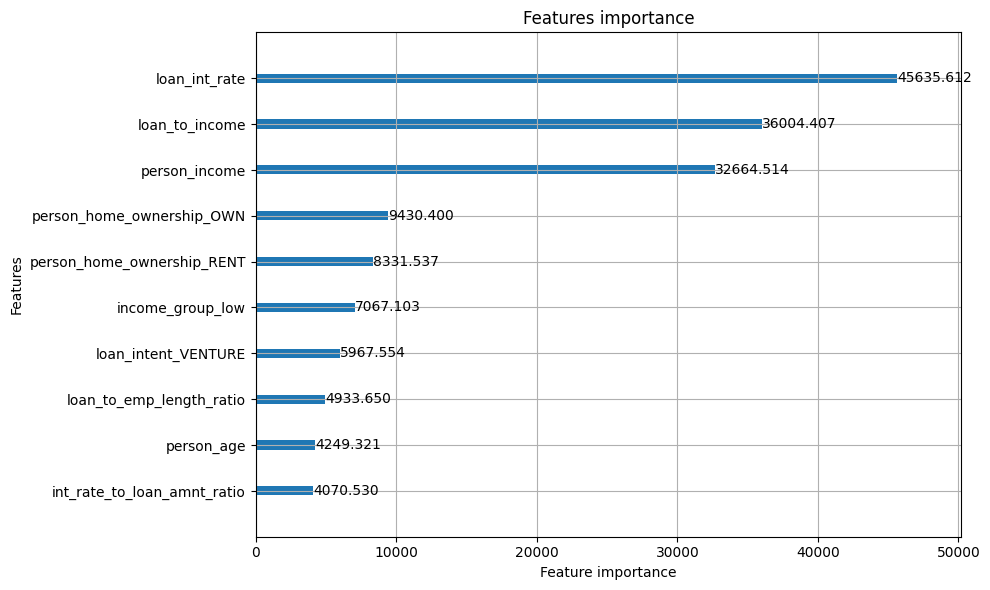

In [14]:
import lightgbm as lgb
import matplotlib.pyplot as plt

model = LGBMClassifier(random_state=42, scale_pos_weight= scale_pos_weight, class_weight="balanced")
model.fit(x_train, y_train)
ax = lgb.plot_importance(model, 
                          max_num_features=10,        
                          importance_type='gain',    
                          figsize=(10, 6))
plt.title("Features importance")
plt.tight_layout()
plt.show()


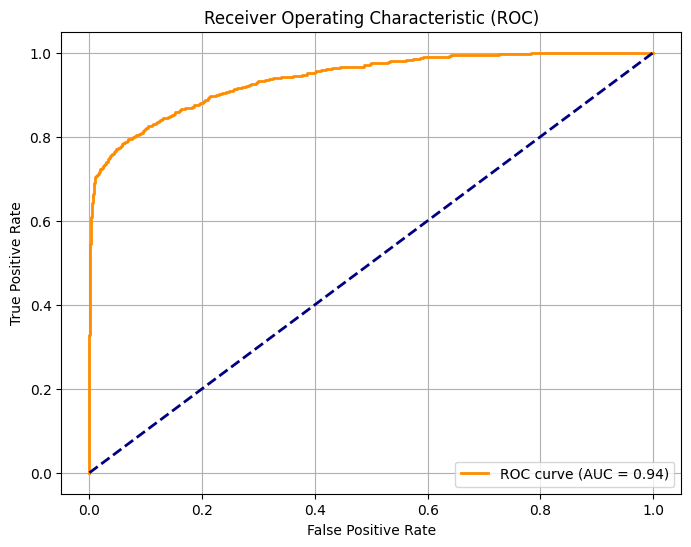

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, x_val, y_val):
    """
    Plot the ROC curve for a binary classification model.
    Parameters:
        model: The trained model that should support the predict_proba method.
        x_val: Validation data (features).
        y_val: The real validation labels
    """
    y_prob = model.predict_proba(x_val)[:, 1]    
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_roc_curve(model, x_val, y_val)


*`Conclusion`* : LightGBM is the most efficient amoung the tested models

## 3. Tuning

In [16]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, roc_auc_score
import numpy as np


In [17]:
scale_pos_weight = len(y_train) / (2.0 * sum(y_train))


In [18]:
import optuna
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, f1_score, recall_score

def objective(trial):
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),  # Handle class imbalance
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),  # Avoid overfitting,
        'verbose' : -1
    }

    # Training
    model = lgb.LGBMClassifier(**param)
    model.fit(x_train, y_train, eval_set=[(x_val, y_val)])

    # Predictions 
    y_pred_prob = model.predict_proba(x_val)[:, 1]
    
    # Adjusting the threshold to prioritize recall
    threshold = 0.3  # Lower threshold to favor recall
    y_pred = (y_pred_prob >= threshold).astype(int)
    
    # Calculating the AUC, F1, and Recall scores
    auc = roc_auc_score(y_val, y_pred_prob)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)

    return recall  # Prioritizing recall for optimization

# Optuna study 
study = optuna.create_study(direction='maximize')  # Maximize recall
study.optimize(objective, n_trials=100) # 100 trials in order to minimize the execution time

# Best Params
params = study.best_params
print("Meilleurs paramètres: ", params)

print("Final Recall after optimization:", study.best_value)


[I 2025-02-25 20:03:17,726] A new study created in memory with name: no-name-7ad6c4a1-d44b-4a5d-8d56-94a52012da50
[I 2025-02-25 20:03:19,302] Trial 0 finished with value: 0.0 and parameters: {'max_depth': 7, 'num_leaves': 83, 'n_estimators': 656, 'scale_pos_weight': 5.058724372994631, 'learning_rate': 4.2090198186313164e-05, 'subsample': 0.7419525085350873, 'colsample_bytree': 0.7171219792760392, 'min_child_samples': 75}. Best is trial 0 with value: 0.0.
[I 2025-02-25 20:03:22,527] Trial 1 finished with value: 0.9622997172478793 and parameters: {'max_depth': 11, 'num_leaves': 98, 'n_estimators': 821, 'scale_pos_weight': 7.813280973419285, 'learning_rate': 0.0024507188218269573, 'subsample': 0.7587011045910524, 'colsample_bytree': 0.7248599000378015, 'min_child_samples': 30}. Best is trial 1 with value: 0.9622997172478793.
[I 2025-02-25 20:03:23,515] Trial 2 finished with value: 0.8803016022620169 and parameters: {'max_depth': 11, 'num_leaves': 74, 'n_estimators': 246, 'scale_pos_weight

Meilleurs paramètres:  {'max_depth': 3, 'num_leaves': 48, 'n_estimators': 144, 'scale_pos_weight': 9.701498521269082, 'learning_rate': 0.009910407140018387, 'subsample': 0.8780227025205483, 'colsample_bytree': 0.8770066345023971, 'min_child_samples': 75}
Final Recall after optimization: 1.0


In [19]:
final_model = lgb.LGBMClassifier(**params)
auc, conf_matrix, class_report, f1, recall = evaluate_model(final_model, x_train, y_train, x_val, y_val)
mlflow.end_run()
with mlflow.start_run(run_name="Finetuned LightGBM"):
    mlflow.log_param("model_name", "Finetuned LightGBM")
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("recall", recall)
    mlflow.log_text(str(conf_matrix), "confusion_matrix.txt")
    mlflow.log_text(class_report, "classification_report.txt")
    mlflow.sklearn.log_model(final_model, artifact_path="Finetuned LightGBM")

2025/02/25 20:05:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
